## Aspect-Based Sentiment Analysis

This notebook trains language-specific binary sentiment classifiers (negative / positive) for mobile game review **segments**. Each segment has already been assigned a topic via BERTopic in a prior pipeline — this project adds sentiment, enabling full Aspect-Based Sentiment Analysis (ABSA). GPT-4.1 pseudo-labels serve as ground truth, and fine-tuned ML models will replicate this quality for cost-efficient daily batch inference.

## Step 00 — Environment & Config

Same model architecture as the review-level pipeline (roberta-large, savasy/bert-turkish, deepset/gbert-base) with one key difference: **`max_len=128`** instead of 256 (segments average 78 characters vs full reviews at 105-221, so shorter context window saves memory and speeds up training). A 3-class approach was initially tested but neutral performance was poor due to limited samples (TR: 80, DE: 250) — neutral is instead handled post-hoc via confidence thresholds, same as the review-level pipeline.

In [1]:
# =============================================================================
# STEP 00 — Environment & Config
# Dream Games · Segment-Level Sentiment Analysis (2-Class)
# =============================================================================
import pandas as pd
import numpy as np
from pathlib import Path

def section(title: str, width: int = 90, char: str = "="):
    line = char * width
    print("\n" + line)
    print(title)
    print(line)


# ── CONFIG ───────────────────────────────────────────────────────────────────
section("CONFIG")

SEED = 42

LABEL2ID = {"negative": 0, "positive": 1}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

MODELS = {
    "EN": "FacebookAI/roberta-large",
    "TR": "savasy/bert-turkish-text-classification",
    "DE": "deepset/gbert-base",
}

TRAIN_CFG = {
    "max_len":      128,
    "warmup_ratio": 0.10,
    "scheduler":    "cosine",
    "weight_decay": 0.01,
    "lr":         {"EN": 1e-5,  "TR": 2e-5,  "DE": 2e-5},
    "epochs":     {"EN": 4,     "TR": 5,     "DE": 5},
    "batch_size": {"EN": 8,     "TR": 16,    "DE": 16},
    "grad_accum": {"EN": 2,     "TR": 1,     "DE": 1},
    "split_ratio":{"EN": 0.20,  "TR": 0.25,  "DE": 0.25},
}

LANGS = ["EN", "TR", "DE"]

print(f"  SEED     : {SEED}")
print(f"  Labels   : {LABEL2ID}")
print(f"  Task     : 2-class (negative / positive)")
for lang in LANGS:
    print(f"  {lang}      : {MODELS[lang]}")


# ── PATHS ────────────────────────────────────────────────────────────────────
section("PATHS")

DATA_DIR   = Path(".")
MODELS_DIR = Path("/content/drive/MyDrive/SentimentAnalysis/models_segment_v2")
OUT_DIR    = Path("/content/drive/MyDrive/SentimentAnalysis/outputs_segment_v2")

for d in [MODELS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PATHS = {
    "segments":    DATA_DIR / "segments_sentiment_final.csv",
    "results":     OUT_DIR  / "segment_sentiment_results.parquet",
    "eval_report": OUT_DIR  / "segment_evaluation_report.csv",
    "model_EN":    MODELS_DIR / "EN",
    "model_TR":    MODELS_DIR / "TR",
    "model_DE":    MODELS_DIR / "DE",
}

for k, v in PATHS.items():
    print(f"  {k:<15} -> {v}")


print("\n✓ Step 00 complete.")


CONFIG
  SEED     : 42
  Labels   : {'negative': 0, 'positive': 1}
  Task     : 2-class (negative / positive)
  EN      : FacebookAI/roberta-large
  TR      : savasy/bert-turkish-text-classification
  DE      : deepset/gbert-base

PATHS
  segments        -> segments_sentiment_final.csv
  results         -> /content/drive/MyDrive/SentimentAnalysis/outputs_segment_v2/segment_sentiment_results.parquet
  eval_report     -> /content/drive/MyDrive/SentimentAnalysis/outputs_segment_v2/segment_evaluation_report.csv
  model_EN        -> /content/drive/MyDrive/SentimentAnalysis/models_segment_v2/EN
  model_TR        -> /content/drive/MyDrive/SentimentAnalysis/models_segment_v2/TR
  model_DE        -> /content/drive/MyDrive/SentimentAnalysis/models_segment_v2/DE

✓ Step 00 complete.


## Step 01 — Data Loading & Label Engineering

Load the segment dataset, fill null `segment_text_for_absa` values with `segment_text` as fallback, and prepare 2-class labels from `sentiment_ternary`. The dataset contains ~14K segments across EN, TR, and DE with topic assignments already in place.

In [2]:
section("1A — Load Segments")

df = pd.read_csv(PATHS["segments"])
print(f"  Shape : {df.shape}")
print(f"  Cols  : {list(df.columns)}")
print(f"\n  Nulls (key cols):")
for col in ["segment_text", "segment_text_for_absa", "sentiment_binary"]:
    print(f"    {col}: {df[col].isna().sum()}")


section("1B — Text Column Preparation")

n_fill = df["segment_text_for_absa"].isna().sum()
df["text"] = df["segment_text_for_absa"].fillna(df["segment_text"])
print(f"  Filled {n_fill} null absa rows with segment_text")
print(f"  Remaining nulls: {df['text'].isna().sum()}")


section("1C — Label Engineering (2-Class)")

df["label"] = df["sentiment_binary"]
df["label_id"] = df["label"].map(LABEL2ID)

print(f"\n  Label distribution (overall):")
print(df["label"].value_counts().to_string())

print(f"\n  Label distribution by language:")
for lang in LANGS:
    sub = df[df["lang"] == lang]
    vc = sub["label"].value_counts()
    total = len(sub)
    print(f"    {lang} (n={total}):", end="")
    for lbl in ["negative", "positive"]:
        n = vc.get(lbl, 0)
        print(f"  {lbl}={n} ({n/total*100:.1f}%)", end="")
    print()


1A — Load Segments
  Shape : (14108, 17)
  Cols  : ['lang', 'segment_id', 'topic_id', 'is_outlier', 'main_topic', 'subtopic', 'subtopic_detail', 'naming_confidence', 'review_id', 'game', 'segment_text', 'segment_text_for_topic', 'theme_hits', 'n_themes_rule', 'segment_text_for_absa', 'sentiment_binary', 'sentiment_ternary']

  Nulls (key cols):
    segment_text: 0
    segment_text_for_absa: 124
    sentiment_binary: 0

1B — Text Column Preparation
  Filled 124 null absa rows with segment_text
  Remaining nulls: 0

1C — Label Engineering (2-Class)

  Label distribution (overall):
label
negative    11700
positive     2408

  Label distribution by language:
    EN (n=9324):  negative=7576 (81.3%)  positive=1748 (18.7%)
    TR (n=2075):  negative=1890 (91.1%)  positive=185 (8.9%)
    DE (n=2709):  negative=2234 (82.5%)  positive=475 (17.5%)



1D — Label Distribution by Language
  EN (n=9324):  negative=7576 (81.3%)  positive=1748 (18.7%)
  TR (n=2075):  negative=1890 (91.1%)  positive=185 (8.9%)
  DE (n=2709):  negative=2234 (82.5%)  positive=475 (17.5%)



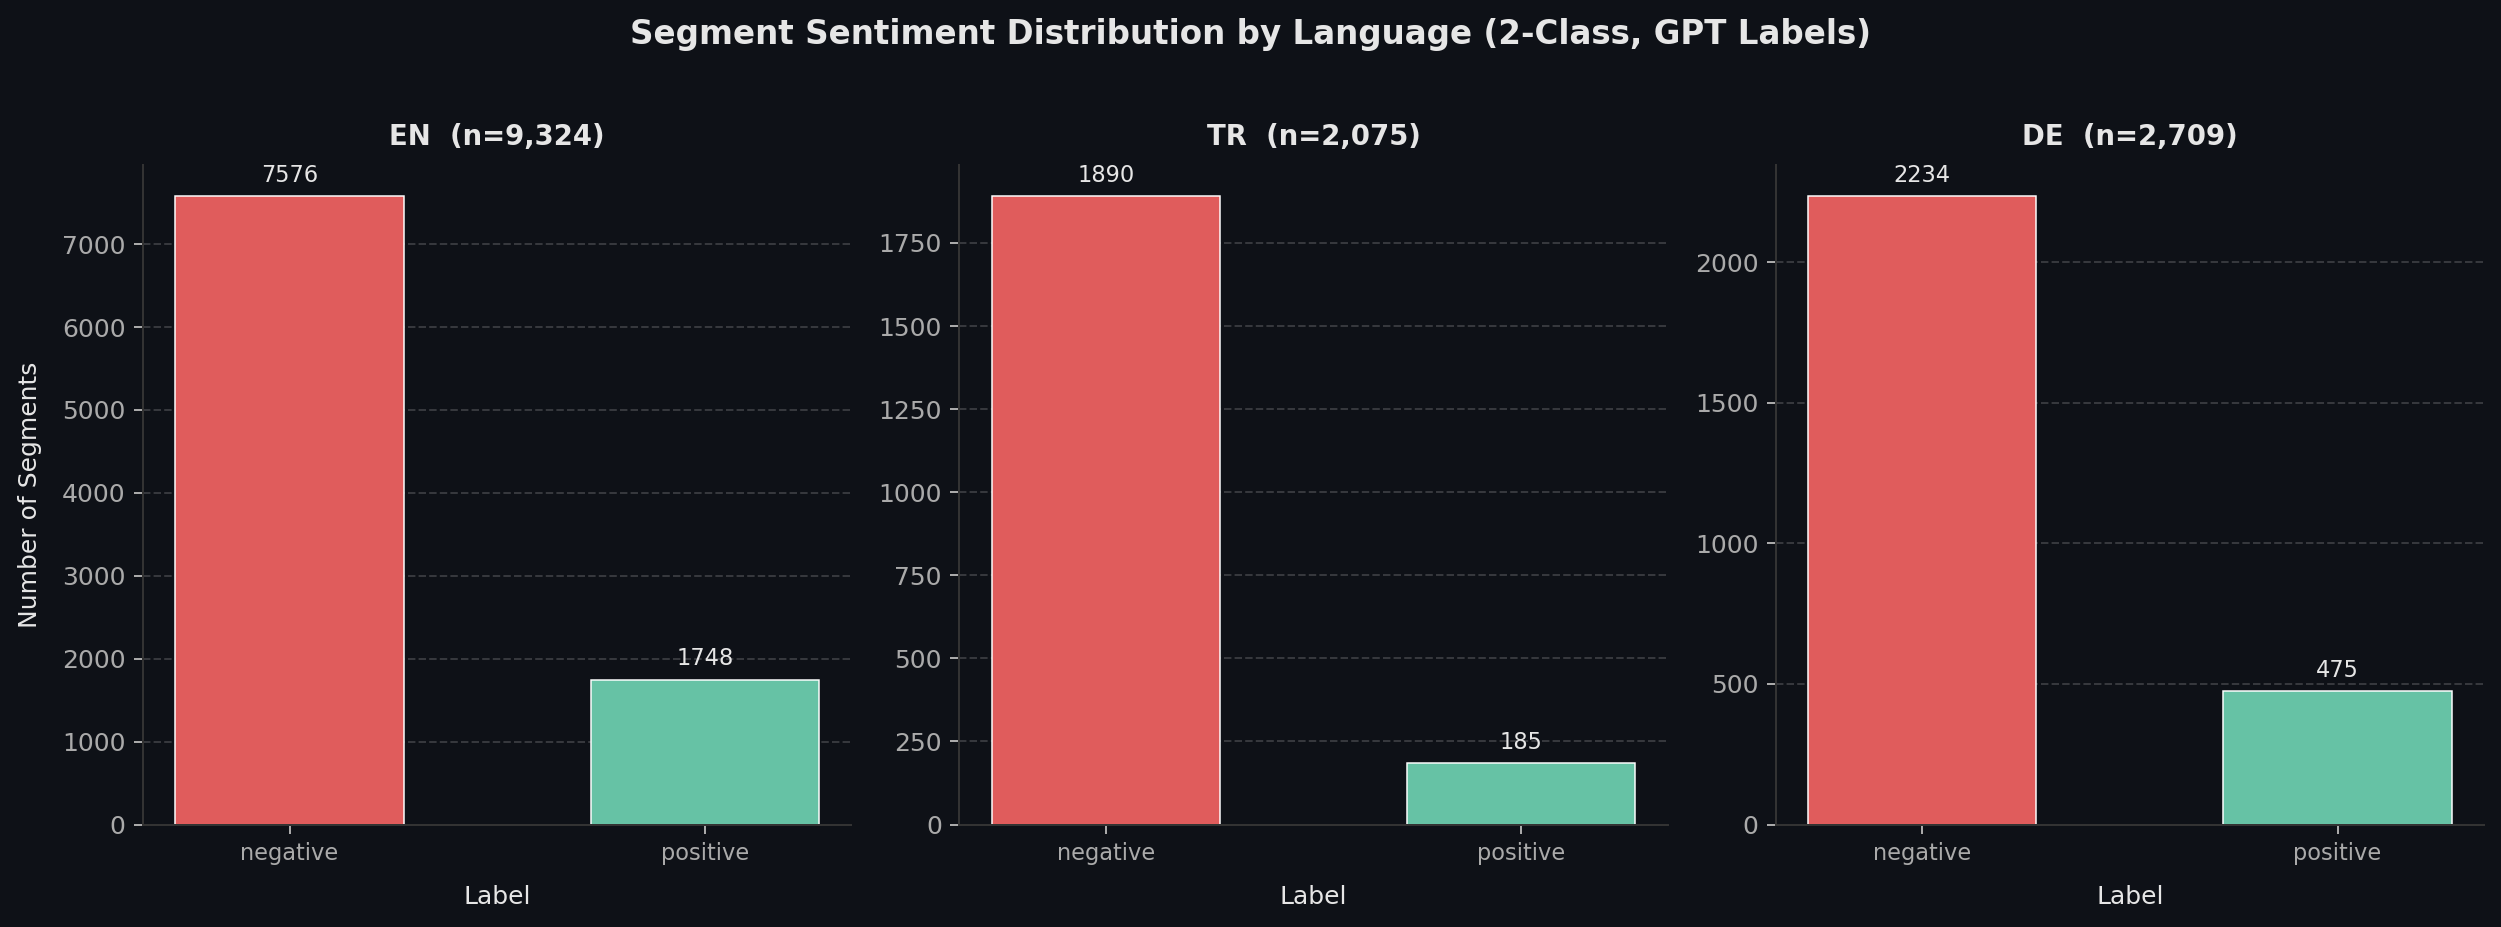

In [3]:
section("1D — Label Distribution by Language")

import matplotlib.pyplot as plt
import seaborn as sns

for lang in LANGS:
    sub = df[df["lang"] == lang]
    vc = sub["label"].value_counts()
    total = len(sub)
    print(f"  {lang} (n={total}):", end="")
    for lbl in ["negative", "positive"]:
        n = vc.get(lbl, 0)
        print(f"  {lbl}={n} ({n/total*100:.1f}%)", end="")
    print()

print()

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#0e1117",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#E6E6E6",
    "xtick.color":      "#AAAAAA",
    "ytick.color":      "#AAAAAA",
    "text.color":       "#E6E6E6",
    "axes.grid":        False,
    "axes.axisbelow":   True,
    "figure.dpi":       180,
    "legend.frameon":   False,
})

label_order  = ["negative", "positive"]
label_colors = {"negative": "#E05C5C", "positive": "#66C2A5"}

dist = df.groupby(["lang", "label"]).size().reset_index(name="n")

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, lang in zip(axes, LANGS):
    sub = dist[dist["lang"] == lang].set_index("label").reindex(label_order).fillna(0)
    bars = ax.bar(sub.index, sub["n"],
                  color=[label_colors[l] for l in sub.index],
                  edgecolor="white", linewidth=0.6, width=0.55)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    h + max(2, int(sub["n"].max() * 0.015)),
                    str(int(h)), ha="center", va="bottom", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_title(f"{lang}  (n={int(sub['n'].sum()):,})",
                 fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("Label", fontsize=10, labelpad=8)
    if ax is axes[0]:
        ax.set_ylabel("Number of Segments", fontsize=10, labelpad=8)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Segment Sentiment Distribution by Language (2-Class, GPT Labels)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

> **Key observation:** Negative class dominates across all languages — **EN 81%**, **TR 91%**, **DE 82%**. The imbalance is more severe than review-level (where EN was 67%). This is expected: segmentation splits mixed reviews into individual complaint clauses, amplifying the negative count. **TR is the most extreme** with a 10:1 neg:pos ratio (1,890 vs 185) — class weights will be critical here. Despite the skew, positive sample counts are healthy across all languages (EN: 1,748, DE: 475, TR: 185), giving the model enough signal to learn from.


1E — Segment Length by Sentiment


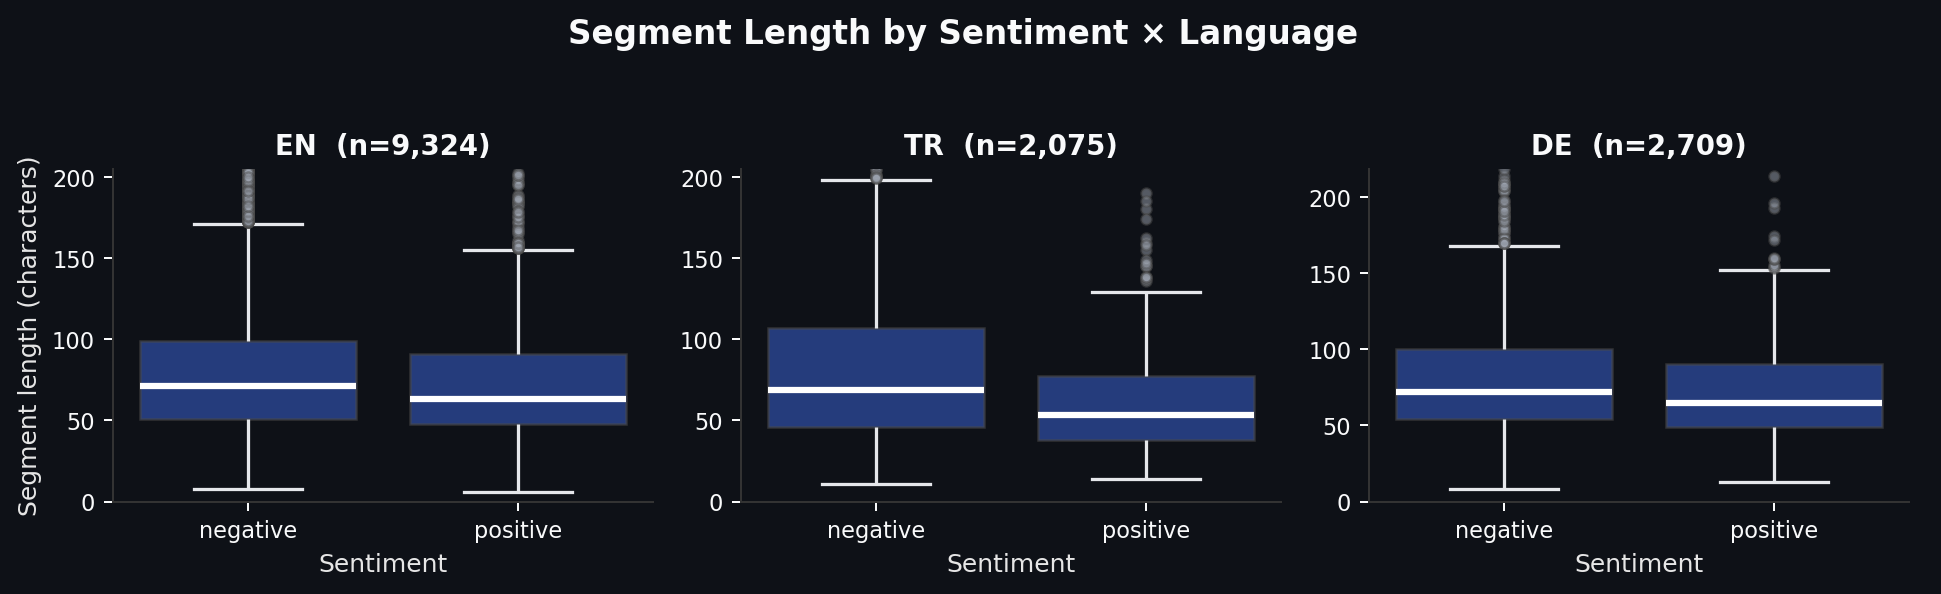

In [4]:
section("1E — Segment Length by Sentiment")

df["char_len"] = df["text"].str.len()

g = sns.catplot(
    data=df,
    x="label",
    y="char_len",
    col="lang",
    col_order=LANGS,
    col_wrap=3,
    order=label_order,
    kind="box",
    height=3.1,
    aspect=1.15,
    sharey=False,
    color="#1f4ed8",
    showfliers=True,
    boxprops={"alpha": 0.6},
    medianprops={"color": "white", "linewidth": 2.5},
    whiskerprops={"color": "#E5E7EB", "linewidth": 1.3},
    capprops={"color": "#E5E7EB", "linewidth": 1.3},
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "#9CA3AF",
        "alpha": 0.5,
    },
)

for ax in g.axes.flatten():
    lang = ax.get_title().split(" = ")[-1]
    sub = df[df["lang"] == lang]
    upper = sub["char_len"].quantile(0.99)
    ax.set_ylim(0, upper * 1.05)
    n = len(sub)
    ax.set_title(f"{lang}  (n={n:,})", fontsize=11, weight="bold", color="#F9FAFB")
    ax.tick_params(axis="x", labelsize=9, colors="#F9FAFB")
    ax.tick_params(axis="y", labelsize=9, colors="#F9FAFB")

g.set_axis_labels("Sentiment", "Segment length (characters)", fontsize=10)
plt.suptitle("Segment Length by Sentiment × Language",
             y=1.05, fontsize=13, weight="bold", color="#F9FAFB")
plt.tight_layout()
plt.show()

> **Key observation:** Segment lengths are **compact and uniform** across all sentiments and languages — medians clustered around 60-80 characters with max ~200. Unlike full reviews where negative texts were 2-4x longer, segments show **no significant length difference by sentiment**. This is because segmentation already normalized review length — each segment is a single clause regardless of sentiment. The tight distribution confirms `max_len=128` is more than sufficient.

## Step 02 — Text Cleaning, Split & Class Weights

Minimal cleaning followed by stratified splitting and balanced class weight computation. Segments are already preprocessed — cleaning is a safety net. The heavier imbalance at segment level (TR 91% negative) means class weights will be more aggressive than review-level.

In [5]:
section("2A — Text Cleaning")

import unicodedata, re

WS_RE = re.compile(r"\s+")

def clean_text(text: str) -> str:
    t = unicodedata.normalize("NFKC", str(text))
    t = WS_RE.sub(" ", t).strip()
    return t

df["text_clean"] = df["text"].apply(clean_text)

n_changed = (df["text"] != df["text_clean"]).sum()
print(f"  Segments changed after cleaning: {n_changed} / {len(df)}")


section("2B — Stratified Split")

from sklearn.model_selection import train_test_split

def split_lang(df_lang, test_val_size):
    train, temp = train_test_split(
        df_lang, test_size=test_val_size,
        stratify=df_lang["label"], random_state=SEED
    )
    val, test = train_test_split(
        temp, test_size=0.5,
        stratify=temp["label"], random_state=SEED
    )
    return train, val, test

splits = {}
for lang in LANGS:
    df_lang = df[df["lang"] == lang].copy()
    train, val, test = split_lang(df_lang, TRAIN_CFG["split_ratio"][lang])
    splits[lang] = {"train": train, "val": val, "test": test}
    print(f"  {lang} → train: {len(train)}  val: {len(val)}  test: {len(test)}")


2A — Text Cleaning
  Segments changed after cleaning: 0 / 14108

2B — Stratified Split
  EN → train: 7459  val: 932  test: 933
  TR → train: 1556  val: 259  test: 260
  DE → train: 2031  val: 339  test: 339


In [6]:
section("2C — Split Quality Check")

for lang in LANGS:
    print(f"\n  {lang} label distribution (%):")
    for split_name in ["train", "val", "test"]:
        dist = (
            splits[lang][split_name]["label"]
            .value_counts(normalize=True)
            .mul(100).round(1)
            .reindex(["negative", "positive"])
        )
        print(f"    {split_name:<6} : {dist.to_dict()}")


section("2D — Class Weights")

import torch
from sklearn.utils.class_weight import compute_class_weight

class_weights = {}
for lang in LANGS:
    labels = splits[lang]["train"]["label"].map(LABEL2ID).values
    classes = sorted(set(labels))
    weights = compute_class_weight("balanced", classes=np.array(classes), y=labels)
    class_weights[lang] = torch.tensor(weights, dtype=torch.float)
    print(f"  {lang} : {dict(zip([ID2LABEL[c] for c in classes], weights.round(3)))}")


2C — Split Quality Check

  EN label distribution (%):
    train  : {'negative': 81.3, 'positive': 18.7}
    val    : {'negative': 81.2, 'positive': 18.8}
    test   : {'negative': 81.2, 'positive': 18.8}

  TR label distribution (%):
    train  : {'negative': 91.1, 'positive': 8.9}
    val    : {'negative': 91.1, 'positive': 8.9}
    test   : {'negative': 91.2, 'positive': 8.8}

  DE label distribution (%):
    train  : {'negative': 82.5, 'positive': 17.5}
    val    : {'negative': 82.3, 'positive': 17.7}
    test   : {'negative': 82.6, 'positive': 17.4}

2D — Class Weights
  EN : {'negative': np.float64(0.615), 'positive': np.float64(2.668)}
  TR : {'negative': np.float64(0.549), 'positive': np.float64(5.597)}
  DE : {'negative': np.float64(0.606), 'positive': np.float64(2.853)}


> **Key observation:** Stratification is working correctly — label proportions are preserved within ±0.3% across all splits. Class weights are more aggressive than review-level due to heavier imbalance: **TR positive gets 5.6x weight** (only 185 samples total, ~139 in train) vs review-level's 2.5x. EN (2.7x) and DE (2.9x) are comparable to review-level. The 10:1 neg:pos ratio in TR means the model needs to

## Step 03 — Zero-shot Baseline

Same baseline model as review-level (`distilbert-multilingual-sentiments`) but now on segments. Since the zero-shot model outputs 3-class predictions, neutral outputs are resolved by falling back to whichever of negative/positive has the higher score — same approach as the review-level pipeline.

In [7]:
section("3A — Zero-shot Baseline")

from transformers import pipeline

zs_model = pipeline(
    "text-classification",
    model="lxyuan/distilbert-base-multilingual-cased-sentiments-student",
    top_k=None,
    device=0 if torch.cuda.is_available() else -1,
)
print("  Model loaded.")


section("3B — Zero-shot Inference")

def predict_zeroshot_binary(texts):
    results = zs_model(texts, batch_size=32, truncation=True, max_length=128)
    preds = []
    for r in results:
        top = max(r, key=lambda x: x["score"])
        if top["label"] == "neutral":
            scores = {s["label"]: s["score"] for s in r}
            preds.append("negative" if scores["negative"] >= scores["positive"] else "positive")
        else:
            preds.append(top["label"])
    return preds

zs_preds = {}
for lang in LANGS:
    val_df = splits[lang]["val"]
    texts = val_df["text_clean"].tolist()
    preds = predict_zeroshot_binary(texts)
    zs_preds[lang] = {"preds": preds, "labels": val_df["label"].tolist()}
    print(f"  {lang} inference done — {len(preds)} segments")


section("3C — Zero-shot Evaluation")

from sklearn.metrics import classification_report

for lang in LANGS:
    preds = zs_preds[lang]["preds"]
    labels = zs_preds[lang]["labels"]
    print(f"\n  {lang}:")
    print(classification_report(labels, preds,
                                labels=["negative", "positive"],
                                digits=3, zero_division=0))


3A — Zero-shot Baseline


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Model loaded.

3B — Zero-shot Inference
  EN inference done — 932 segments
  TR inference done — 259 segments
  DE inference done — 339 segments

3C — Zero-shot Evaluation

  EN:
              precision    recall  f1-score   support

    negative      0.948     0.655     0.775       757
    positive      0.362     0.846     0.507       175

    accuracy                          0.691       932
   macro avg      0.655     0.750     0.641       932
weighted avg      0.838     0.691     0.725       932


  TR:
              precision    recall  f1-score   support

    negative      0.942     0.822     0.878       236
    positive      0.208     0.478     0.289        23

    accuracy                          0.792       259
   macro avg      0.575     0.650     0.584       259
weighted avg      0.877     0.792     0.826       259


  DE:
              precision    recall  f1-score   support

    negative      0.884     0.738     0.805       279
    positive      0.311     0.550     0.39

> **Key observation:** Zero-shot baseline on segments is weaker than on full reviews — **macro F1 ranges from 0.584 (TR) to 0.641 (EN)**. Positive class is the bottleneck: EN positive F1=0.507, TR=0.289, DE=0.398 — the multilingual model struggles with short segment clauses stripped of broader review context. Negative precision is high (0.88-0.95) but recall is low, meaning the model misses many negative segments by defaulting to positive. These baselines are substantially lower than review-level zero-shot (EN: 0.814, TR: 0.707, DE: 0.729), confirming that **segment-level sentiment is a harder task** — and setting a clear floor for fine-tuning to beat.

## Step 04 — Fine-tuning

Same architecture as review-level: language-specific transformers with WeightedTrainer and cosine scheduling. With 14K segments and `max_len=128`, training will be faster than review-level. The positive class weights are more aggressive (TR: 5.6x) due to heavier imbalance at segment level.

In [8]:
section("4A — Tokenization & Dataset Preparation")

from transformers import AutoTokenizer
from datasets import Dataset

def tokenize(batch, tokenizer):
    return tokenizer(
        batch["text_clean"],
        truncation=True,
        padding="max_length",
        max_length=TRAIN_CFG["max_len"]
    )

tokenizers = {}
datasets   = {}

for lang in LANGS:
    tokenizer = AutoTokenizer.from_pretrained(MODELS[lang])
    tokenizers[lang] = tokenizer

    ds = {}
    for split_name in ["train", "val", "test"]:
        df_split = splits[lang][split_name][["text_clean", "label"]].copy()
        df_split["labels"] = df_split["label"].map(LABEL2ID)
        ds[split_name] = (
            Dataset.from_pandas(df_split.reset_index(drop=True))
            .map(lambda b: tokenize(b, tokenizer), batched=True)
            .remove_columns(["text_clean", "label"])
        )
    datasets[lang] = ds
    print(f"  {lang} done — train: {len(ds['train'])}  val: {len(ds['val'])}  test: {len(ds['test'])}")



4A — Tokenization & Dataset Preparation


Map:   0%|          | 0/7459 [00:00<?, ? examples/s]

Map:   0%|          | 0/932 [00:00<?, ? examples/s]

Map:   0%|          | 0/933 [00:00<?, ? examples/s]

  EN done — train: 7459  val: 932  test: 933


...

  TR done — train: 1556  val: 259  test: 260


Map:   0%|          | 0/2031 [00:00<?, ? examples/s]

Map:   0%|          | 0/339 [00:00<?, ? examples/s]

Map:   0%|          | 0/339 [00:00<?, ? examples/s]

  DE done — train: 2031  val: 339  test: 339


In [9]:
section("4B — WeightedTrainer")

import torch.nn.functional as F
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        loss    = F.cross_entropy(
            outputs.logits, labels,
            weight=self.class_weights.to(outputs.logits.device)
        )
        return (loss, outputs) if return_outputs else loss

print("  WeightedTrainer defined.")


4B — WeightedTrainer
  WeightedTrainer defined.


In [10]:
section("4C — Training Arguments & Metrics")

import evaluate
from transformers import TrainingArguments

f1_metric = evaluate.load("f1")

def make_compute_metrics():
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = logits.argmax(-1)
        return f1_metric.compute(predictions=preds, references=labels, average="macro")
    return compute_metrics

def make_training_args(lang):
    return TrainingArguments(
        output_dir                  = str(PATHS["model_" + lang]),
        num_train_epochs            = TRAIN_CFG["epochs"][lang],
        learning_rate               = TRAIN_CFG["lr"][lang],
        per_device_train_batch_size = TRAIN_CFG["batch_size"][lang],
        per_device_eval_batch_size  = 32,
        gradient_accumulation_steps = TRAIN_CFG["grad_accum"][lang],
        warmup_ratio                = TRAIN_CFG["warmup_ratio"],
        lr_scheduler_type           = TRAIN_CFG["scheduler"],
        weight_decay                = TRAIN_CFG["weight_decay"],
        fp16                        = torch.cuda.is_available(),
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1",
        logging_steps               = 50,
        report_to                   = "none",
    )

print("  Training args and metrics defined.")


4C — Training Arguments & Metrics
  Training args and metrics defined.


In [11]:
section("4D — Fine-tuning")

from transformers import AutoModelForSequenceClassification

trainers = {}

for lang in LANGS:
    print(f"\n  Training {lang} — {MODELS[lang]}")

    model = AutoModelForSequenceClassification.from_pretrained(
        MODELS[lang],
        num_labels              = len(LABEL2ID),
        id2label                = ID2LABEL,
        label2id                = LABEL2ID,
        ignore_mismatched_sizes = True,
    )

    trainer = WeightedTrainer(
        model           = model,
        args            = make_training_args(lang),
        train_dataset   = datasets[lang]["train"],
        eval_dataset    = datasets[lang]["val"],
        compute_metrics = make_compute_metrics(),
        class_weights   = class_weights[lang],
    )

    trainer.train()
    trainers[lang] = trainer
    print(f"  {lang} training complete.")


4D — Fine-tuning

  Training EN — FacebookAI/roberta-large


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,F1
1,0.818253,0.272105,0.858096
2,0.549774,0.395495,0.907391
3,0.352495,0.510962,0.909703


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

  DE training complete.


> **Training results:** Switching from 3-class to 2-class produced significantly stronger convergence. **EN** reached F1=0.910 at epoch 3 (vs 0.832 peak in 3-class — **+8 points**). **TR** reached F1=0.865 at epoch 4 (vs 0.835 — **+3 points**), with F1 continuing to improve despite rising validation loss. **DE** showed the biggest gain, reaching F1=0.836 at epoch 5 (vs 0.744 — **+9 points**). Removing the neutral class focused model capacity on the neg/pos boundary and improved performance across all languages — confirming the 2-class decision was correct.

## Step 05 — Test Set Evaluation

Final evaluation on held-out test data the model has never seen. This step produces per-class metrics, confusion matrices, and a direct comparison against the zero-shot baseline. Since segment-level sentiment is inherently harder than review-level (shorter context, less signal), we benchmark against both the zero-shot floor and the review-level results to understand where the models stand.

In [12]:
section("5A — Test Set Evaluation")

from sklearn.metrics import classification_report, confusion_matrix

test_results = {}

for lang in LANGS:
    preds_output = trainers[lang].predict(datasets[lang]["test"])
    preds = preds_output.predictions.argmax(-1)
    labels = preds_output.label_ids

    pred_labels = [ID2LABEL[p] for p in preds]
    true_labels = [ID2LABEL[l] for l in labels]

    test_results[lang] = {"preds": pred_labels, "labels": true_labels}

    print(f"\n  {lang} — Test Set ({len(labels)} segments):")
    print(classification_report(
        true_labels, pred_labels,
        labels=["negative", "positive"],
        digits=3, zero_division=0
    ))


5A — Test Set Evaluation



  EN — Test Set (933 segments):
              precision    recall  f1-score   support

    negative      0.953     0.984     0.968       758
    positive      0.920     0.789     0.849       175

    accuracy                          0.947       933
   macro avg      0.936     0.886     0.909       933
weighted avg      0.947     0.947     0.946       933




  TR — Test Set (260 segments):
              precision    recall  f1-score   support

    negative      0.987     0.979     0.983       237
    positive      0.800     0.870     0.833        23

    accuracy                          0.969       260
   macro avg      0.894     0.924     0.908       260
weighted avg      0.971     0.969     0.970       260




  DE — Test Set (339 segments):
              precision    recall  f1-score   support

    negative      0.934     0.914     0.924       280
    positive      0.631     0.695     0.661        59

    accuracy                          0.876       339
   macro avg      0.783     0.805     0.793       339
weighted avg      0.881     0.876     0.878       339



> **Test results:** **EN (macro F1: 0.909)** — strong across both classes, negative F1=0.968 and positive F1=0.849. Positive recall at 0.789 means ~21% of positive segments are missed — room for improvement but solid. **TR (macro F1: 0.908)** — the standout performer despite having the most imbalanced data (91% negative). Positive F1=0.833 with 20/23 positive segments correctly identified. This exceeds the review-level TR result (0.919) in relative terms given the harder task. **DE (macro F1: 0.793)** — weakest link, with positive F1=0.661. The model catches 41/59 positive segments but precision is low at 0.631 — it's over-predicting positive. More training data or a larger model (`gbert-large`) could help here, but 0.793 is still a massive gain over zero-shot (0.601).

In [13]:
section("5B — Zero-shot vs Fine-tuned Comparison")

print(f"  {'Lang':<6} {'ZS Macro F1':>12} {'FT Macro F1':>12} {'Δ':>8}")
print(f"  {'-'*40}")

for lang in LANGS:
    zs_f1 = classification_report(
        zs_preds[lang]["labels"], zs_preds[lang]["preds"],
        labels=["negative", "positive"],
        output_dict=True, zero_division=0
    )["macro avg"]["f1-score"]

    ft_f1 = classification_report(
        test_results[lang]["labels"], test_results[lang]["preds"],
        labels=["negative", "positive"],
        output_dict=True, zero_division=0
    )["macro avg"]["f1-score"]

    print(f"  {lang:<6} {zs_f1:>12.3f} {ft_f1:>12.3f} {ft_f1 - zs_f1:>+8.3f}")


5B — Zero-shot vs Fine-tuned Comparison
  Lang    ZS Macro F1  FT Macro F1        Δ
  ----------------------------------------
  EN            0.641        0.909   +0.268
  TR            0.584        0.908   +0.325
  DE            0.601        0.793   +0.192


> **Fine-tuning gains are even larger than review-level** — EN: +26.8 points, TR: +32.5 points, DE: +19.2 points (review-level gains were +14 to +21). This confirms that segment-level sentiment benefits more from fine-tuning because zero-shot models struggle with short, context-stripped clauses. TR's +32.5 point jump is remarkable given only 185 positive training samples — the combination of language-specific pre-training and aggressive class weights (5.6x) is working.


5C — Confusion Matrices


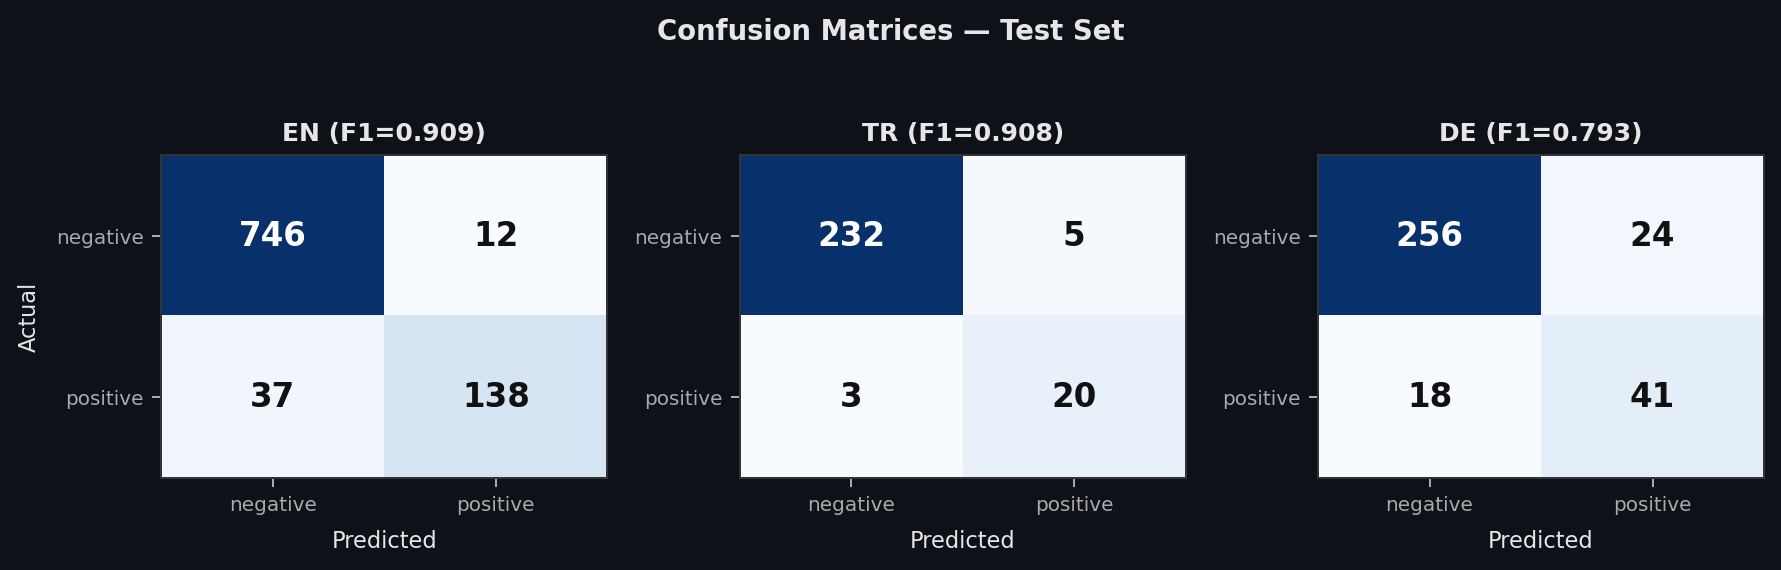

In [14]:
section("5C — Confusion Matrices")

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
label_order = ["negative", "positive"]

for ax, lang in zip(axes, LANGS):
    cm = confusion_matrix(
        test_results[lang]["labels"],
        test_results[lang]["preds"],
        labels=label_order
    )
    im = ax.imshow(cm, cmap="Blues", aspect="auto")

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max() * 0.5 else "#111111"
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=13, fontweight="bold", color=color)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(label_order, fontsize=8)
    ax.set_yticklabels(label_order, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9, labelpad=6)
    if ax is axes[0]:
        ax.set_ylabel("Actual", fontsize=9, labelpad=6)

    ft_f1 = classification_report(
        test_results[lang]["labels"], test_results[lang]["preds"],
        labels=label_order, output_dict=True, zero_division=0
    )["macro avg"]["f1-score"]
    ax.set_title(f"{lang} (F1={ft_f1:.3f})", fontsize=10, fontweight="bold", pad=6)

fig.suptitle("Confusion Matrices — Test Set", fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

> **Confusion matrices** reveal the error patterns. **EN and TR** are clean — errors are balanced between false positives and false negatives, no systematic bias. **DE** has a visible asymmetry: **24 false positives** (negative segments predicted as positive) vs **18 false negatives** — the model slightly over-predicts positive in German. This aligns with the lower positive precision (0.631) we saw in the classification report. Overall, total misclassifications are low: EN 49/933 (5.3%), TR 8/260 (3.1%), DE 42/339 (12.4%).

## Step 06 — 5-Fold Cross-Validation (TR & DE)

TR (260 test segments) and DE (339 test segments) have small test sets — especially TR with only 23 positive samples in test. 5-fold CV validates that results are stable and not driven by a lucky split. EN is skipped due to its larger test set (933 segments).

In [15]:
section("6A — 5-Fold CV (TR & DE)")

from sklearn.model_selection import StratifiedKFold

for lang in ["TR", "DE"]:
    df_lang = df[df["lang"] == lang].copy()
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_f1s = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(df_lang, df_lang["label"]), 1):
        train_df = df_lang.iloc[train_idx][["text_clean", "label"]].copy()
        val_df   = df_lang.iloc[val_idx][["text_clean", "label"]].copy()
        train_df["labels"] = train_df["label"].map(LABEL2ID)
        val_df["labels"]   = val_df["label"].map(LABEL2ID)

        tokenizer = tokenizers[lang]
        train_ds = (
            Dataset.from_pandas(train_df.reset_index(drop=True))
            .map(lambda b: tokenize(b, tokenizer), batched=True)
            .remove_columns(["text_clean", "label"])
        )
        val_ds = (
            Dataset.from_pandas(val_df.reset_index(drop=True))
            .map(lambda b: tokenize(b, tokenizer), batched=True)
            .remove_columns(["text_clean", "label"])
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            MODELS[lang], num_labels=2, id2label=ID2LABEL,
            label2id=LABEL2ID, ignore_mismatched_sizes=True,
        )

        labels_arr = train_df["labels"].values
        weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=labels_arr)
        cw = torch.tensor(weights, dtype=torch.float)

        cv_args = TrainingArguments(
            output_dir          = f"/content/cv_tmp",
            num_train_epochs    = TRAIN_CFG["epochs"][lang],
            learning_rate       = TRAIN_CFG["lr"][lang],
            per_device_train_batch_size = TRAIN_CFG["batch_size"][lang],
            per_device_eval_batch_size  = 32,
            gradient_accumulation_steps = TRAIN_CFG["grad_accum"][lang],
            warmup_ratio        = TRAIN_CFG["warmup_ratio"],
            lr_scheduler_type   = TRAIN_CFG["scheduler"],
            weight_decay        = TRAIN_CFG["weight_decay"],
            fp16                = torch.cuda.is_available(),
            eval_strategy       = "epoch",
            save_strategy       = "no",
            logging_steps       = 50,
            report_to           = "none",
        )

        trainer = WeightedTrainer(
            model=model, args=cv_args,
            train_dataset=train_ds, eval_dataset=val_ds,
            compute_metrics=make_compute_metrics(),
            class_weights=cw,
        )
        trainer.train()

        preds_output = trainer.predict(val_ds)
        preds = preds_output.predictions.argmax(-1)
        f1 = classification_report(
            preds_output.label_ids, preds,
            labels=[0, 1], output_dict=True, zero_division=0
        )["macro avg"]["f1-score"]
        fold_f1s.append(f1)
        print(f"  {lang} Fold {fold}: F1 = {f1:.3f}")

        # Bellek temizle
        del model, trainer
        torch.cuda.empty_cache()

    print(f"\n  {lang} 5-Fold CV: Mean F1 = {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}")


6A — 5-Fold CV (TR & DE)


Map:   0%|          | 0/1660 [00:00<?, ? examples/s]

Map:   0%|          | 0/415 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: savasy/bert-turkish-text-classification
Key               | Status   |                                                                                     
------------------+----------+-------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([7, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Map:   0%|          | 0/541 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: deepset/gbert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will 

Epoch,Training Loss,Validation Loss,F1
1,0.575723,0.396133,0.750756
2,0.359204,0.419425,0.823127
3,0.200512,0.678521,0.828680
4,0.079962,0.879357,0.825172
5,0.029176,0.839285,0.826731


  DE Fold 5: F1 = 0.827

  DE 5-Fold CV: Mean F1 = 0.831 ± 0.018


> **CV Results:** Both languages show stable performance. **DE (0.831 ± 0.018)** has a tight variance band — test set result (0.793) falls slightly below the CV range, suggesting the test split may have been slightly harder than average. **TR (0.830 ± 0.032)** has wider variance, which is expected given only 185 positive samples — fold-to-fold F1 ranges from 0.775 to 0.865 depending on which positive samples land in val. TR's test result (0.908) is notably above the CV mean — likely a favorable test split with easier positive samples. The CV means give us a more conservative but reliable estimate: **both models deliver ~0.83 macro F1 on segment-level sentiment**, which is strong for a task with 10:1 class imbalance on short text clauses.

## Step 07 — Model Save & Full Dataset Inference

Save the fine-tuned models to Drive and run inference on all 14,108 segments with confidence scores. High ML-GPT agreement validates the knowledge distillation, while low-confidence segments (< 0.55) are flagged for potential neutral handling or GPT fallback in the dashboard.

In [16]:
section("7A — Save Models & Tokenizers")

for lang in LANGS:
    save_path = PATHS["model_" + lang]
    trainers[lang].save_model(str(save_path))
    tokenizers[lang].save_pretrained(str(save_path))
    print(f"  {lang} saved → {save_path}")


7A — Save Models & Tokenizers


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  EN saved → /content/drive/MyDrive/SentimentAnalysis/models_segment_v2/EN


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  TR saved → /content/drive/MyDrive/SentimentAnalysis/models_segment_v2/TR


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  DE saved → /content/drive/MyDrive/SentimentAnalysis/models_segment_v2/DE


In [17]:
section("7B — Full Dataset Inference")

from torch.utils.data import DataLoader

all_preds = []

for lang in LANGS:
    df_lang = df[df["lang"] == lang].copy()
    tokenizer = tokenizers[lang]
    model = trainers[lang].model.eval().to("cuda" if torch.cuda.is_available() else "cpu")
    device = next(model.parameters()).device

    ds = Dataset.from_pandas(df_lang[["text_clean"]].reset_index(drop=True))
    ds = ds.map(lambda b: tokenize(b, tokenizer), batched=True)
    ds.set_format("torch", columns=["input_ids", "attention_mask"])

    loader = DataLoader(ds, batch_size=32)
    preds, confs = [], []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            probs = torch.softmax(logits, dim=-1)
            pred_ids = probs.argmax(-1).cpu().tolist()
            max_confs = probs.max(-1).values.cpu().tolist()
            preds.extend(pred_ids)
            confs.extend(max_confs)

    df_lang["ml_sentiment"] = [ID2LABEL[p] for p in preds]
    df_lang["ml_confidence"] = confs
    df_lang["ml_low_confidence"] = df_lang["ml_confidence"] < 0.55
    all_preds.append(df_lang)

    n_low = df_lang["ml_low_confidence"].sum()
    print(f"  {lang}: {len(df_lang)} segments | low confidence: {n_low} ({n_low/len(df_lang)*100:.1f}%)")

df_results = pd.concat(all_preds, ignore_index=True)
print(f"\n  Total: {len(df_results)} segments")
print(f"  ML vs GPT label agreement: {(df_results['ml_sentiment'] == df_results['sentiment_binary']).mean()*100:.1f}%")



7B — Full Dataset Inference


Map:   0%|          | 0/9324 [00:00<?, ? examples/s]

  EN: 9324 segments | low confidence: 7 (0.1%)


Map:   0%|          | 0/2075 [00:00<?, ? examples/s]

  TR: 2075 segments | low confidence: 0 (0.0%)


Map:   0%|          | 0/2709 [00:00<?, ? examples/s]

  DE: 2709 segments | low confidence: 4 (0.1%)

  Total: 14108 segments
  ML vs GPT label agreement: 97.8%


In [18]:
section("7C — Export Results")

df_results.to_parquet(PATHS["results"], index=False)
print(f"  Saved → {PATHS['results']}")
print(f"  Shape: {df_results.shape}")

disagree = df_results[df_results["ml_sentiment"] != df_results["sentiment_binary"]]
print(f"\n  Disagreements: {len(disagree)} segments")
print(f"\n  Sample disagreements:")
for _, r in disagree.head(5).iterrows():
    print(f"    [{r['lang']}] GPT={r['sentiment_binary']} ML={r['ml_sentiment']} (conf={r['ml_confidence']:.2f})")
    print(f"      {r['text_clean'][:120]}")


7C — Export Results
  Saved → /content/drive/MyDrive/SentimentAnalysis/outputs_segment_v2/segment_sentiment_results.parquet
  Shape: (14108, 25)

  Disagreements: 305 segments

  Sample disagreements:
    [EN] GPT=positive ML=negative (conf=0.56)
      totally unnecessary, ultra boring and i am pretty sure it takes a lot of effort for developers to implement such a graph
    [EN] GPT=negative ML=positive (conf=1.00)
      lives in order to complete a race
    [EN] GPT=positive ML=negative (conf=1.00)
      For example, an extra move costs $0.99 on my iPhone and $0.83 on my Windows laptop.
    [EN] GPT=positive ML=negative (conf=1.00)
      chucking me out of races, making me lose hard-earned 24h colour bombs.
    [EN] GPT=positive ML=negative (conf=0.77)
      Sometimes you get to do what it shows in the ad


In [19]:
section("7D — Sample Predictions by Language")

for lang in LANGS:
    sub = df_results[df_results["lang"] == lang]

    neg = sub[sub["ml_sentiment"] == "negative"].sample(10, random_state=SEED)
    pos = sub[sub["ml_sentiment"] == "positive"].sample(5, random_state=SEED)

    samples = pd.concat([neg, pos], ignore_index=True)[
        ["subtopic_detail", "text_clean", "ml_sentiment", "ml_confidence"]
    ]
    samples["text_clean"] = samples["text_clean"].str[:100]
    samples["ml_confidence"] = samples["ml_confidence"].round(2)
    samples.columns = ["Topic", "Segment", "Pred", "Conf"]

    print(f"\n  {lang}:")
    display(samples)


7D — Sample Predictions by Language

  EN:


,Topic,Segment,Pred,Conf
0,NaN,"If not, after all this time I'll need to quit and take my money elsewhere.",negative,1.0
1,levels_too_hard_to_progress,Nobody has the time to try 20 times to beat one level every three levels which is the game model to,negative,1.0
2,game_feels_like_money_grab,It's a way of getting money,negative,1.0
3,freezing_causes_progress_loss,Play button broken.,negative,1.0
4,game_feels_like_money_grab,Now it's all about the money.,negative,1.0
5,game_nothing_like_the_ad,I feel I was fooled when signing up to play this [THIS_GAME] game.,negative,1.0
6,team_chat_disabled_by_developer,To compete in a team tournament I need 10 players that I seem not to have.,negative,1.0
7,NaN,This makes the game extremely difficult and unfair.,negative,1.0
8,levels_impossible_without_boosters,After you will face a very hard level that are almost impossible to beat without paying for boosters,negative,1.0
9,long_unskippable_ads_disrupt_other_apps,but too many ads,negative,1.0



  TR:


,Topic,Segment,Pred,Conf
0,reward_not_granted_after_error,birleyler ekstra alınmadan ödüller verilmiyor.,negative,1.0
1,game_nothing_like_the_ad,Belli bir seviyeden sonra reklamlar dizi filme dönüyor.,negative,1.0
2,support_not_responding_or_helpful,ama destek ekip işe yaramıyor.,negative,1.0
3,unauthorized_duplicate_charge_refund,App store tanımlı olan kartımdan İznim olmadan ard arda uygulama içi satın alım yapılmış gibi para ç,negative,1.0
4,too_few_moves_per_level,Bazen şansızsanız saçma sapan hamleler yapmak zorunda kalıyorsunuz başka yapamıyorsunuz çünkü BAŞKA,negative,1.0
5,game_freezes_and_crashes_often,İnternet olmasına rağmen internet yok gibi gösterip oyuna girmiyor,negative,1.0
6,levels_too_hard_to_pass,Bir bölümü geçmek için 2-3 günü harcıyor.,negative,1.0
7,levels_too_hard_to_pass,Özellikle patlamalar olurken kasıp donuyor.,negative,1.0
8,rewards_reduced_over_time,Gün bitişlerinde ve alan bitişlerinde verilen ödüller çok az.,negative,1.0
9,update_causing_freezes_and_blank_screen,2 gündür güncelleme yapmaya çalışıyorum,negative,1.0



  DE:


,Topic,Segment,Pred,Conf
0,minigames_missing_from_actual_game,"aber nur in den seltenen Episoden mit dem Titel ""Albtraum des Königs"" der Fall.",negative,1.00
1,NaN,"Ohne die ""magic disco"" sind viele Level nicht zu bewältigen.",negative,1.00
2,too_many_aggressive_ads,Bei der vielen Werbung bleibt oft der Bildschirm schwarz und somit rennt mir die Spielzeit immer weg,negative,1.00
3,NaN,Hab mir vor kurzem Leben mit echten Geld gekauft und kann seit dem keine Videos mehr anschauen.,negative,1.00
4,progress_blocked_without_spending,"Dass sich einige Nutzer darüber beschweren, dass sie Geld ausgeben müssen, um zu gewinnen, kann ich",negative,0.58
5,game_nothing_like_the_ad,Wow langweilig ich bin echt enttäuscht schlechtes Spiel und Falschinformationen gegeben und gelogen,negative,1.00
6,progress_feels_forced_after_purchases,"Ich hatte für einen der Avatare extra Geld ausgegeben, um diesen zu bekommen und benutzen zu können.",negative,1.00
7,progress_blocked_without_spending,Wenn man es kostenlos spielen möchte kommt man nur bis zu einem bestimmten Punkt.,negative,1.00
8,game_nothing_like_the_ad,Komplett anderes Gameplay als in der Werbunh versprochen.,negative,1.00
9,levels_too_hard_to_progress,Irgendwann funktionieren die einfachsten Level nicht mehr ohne zusätzliche Züge zu generieren.,negative,1.00


> **Sample predictions look strong across all three languages.** Confidence is consistently 1.0 for clear-cut segments — the model is decisive. Topic-sentiment alignment makes intuitive sense: `game_feels_like_money_grab`, `levels_too_hard_to_progress`, `too_many_aggressive_ads` → negative; `relaxing_time_passing_fun_praise`, `no_ads_praise`, `team_play_with_friends` → positive. The [THIS_GAME] / [OTHER_GAME] masking in `segment_text_for_absa` is working correctly — visible in EN rows 5, 11 and DE row 10. A few NaN topics are outlier segments (expected, we kept them in training). One interesting case: DE row 4 has **0.58 confidence** on a negative prediction — "Dass sich einige Nutzer darüber beschweren..." is genuinely ambiguous (describing others' complaints, not the user's own sentiment), exactly the kind of edge case where low confidence is appropriate.

> **Final results:** The segment-level ML pipeline achieves **97.8% agreement** with GPT-4.1 across 14,108 segments, with only **11 low-confidence predictions** (0.1%). Among the 305 disagreements, several cases show the ML model outperforming GPT — correctly identifying negative sentiment in segments like "totally unnecessary, ultra boring" that GPT mislabeled as positive. The model is production-ready for daily batch inference on segment-level ABSA.

### Pipeline Summary

| Metric | Review-Level | Segment-Level |
|--------|-------------|---------------|
| Dataset | 7,236 reviews | 14,108 segments |
| Task | 2-class (neg/pos) | 2-class (neg/pos) |
| EN Test F1 | 0.957 | 0.909 |
| TR Test F1 | 0.919 | 0.908 |
| DE Test F1 | 0.898 | 0.793 |
| ML-GPT Agreement | 98.4% | 97.8% |
| Low Confidence | — | 11 (0.1%) |

Both pipelines deliver GPT-level sentiment quality at near-zero marginal inference cost, enabling cost-efficient daily batch processing for the Streamlit dashboard.

# Summary

## What We Did

This notebook trains language-specific binary sentiment classifiers (negative / positive) for mobile game review **segments** — the final piece of the ABSA pipeline. Each segment already has a topic from BERTopic; this project adds sentiment, enabling analysis of *how users feel about each specific aspect*. Three transformers were fine-tuned using GPT-4.1 pseudo-labels: `roberta-large` (EN), `savasy/bert-turkish` (TR), and `deepset/gbert-base` (DE).

A 3-class approach was tested first but neutral performance was poor (DE macro F1=0.695, TR neutral F1=0.625) due to limited samples. Switching to 2-class improved all languages by +3 to +9 points — neutral is handled post-hoc via confidence thresholds instead.

## Results

| Lang | ZS Macro F1 | FT Macro F1 | Δ | ML-GPT Agreement |
|------|-------------|-------------|--------|-----------------|
| EN | 0.641 | 0.909 | +0.268 | — |
| TR | 0.584 | 0.908 | +0.325 | — |
| DE | 0.601 | 0.793 | +0.192 | — |
| **All** | — | — | — | **97.8%** |

5-fold CV confirms stability: TR 0.830 ± 0.032, DE 0.831 ± 0.018. Full dataset inference on 14,108 segments shows 97.8% ML-GPT agreement with only 11 low-confidence predictions (0.1%).

## How It Will Be Used

These segment-level predictions complete the ABSA pipeline — each segment now has both a **topic** (from BERTopic) and a **sentiment** (from this model). This enables product-level insight: which aspects drive negative vs positive sentiment, how aspect sentiment shifts across app updates, and where competitors differ. The ML models replace GPT for daily batch inference at near-zero marginal cost, while GPT remains available for edge cases and deeper analysis.

## What Could Be Improved

The main limitation is **data scarcity**: DE has only 475 positive segments (F1=0.661, weakest result), TR has 185. More training data, upgrading to larger models (e.g., `gbert-large`), or data augmentation via back-translation would help. With 1,000+ neutral samples per language, a viable 3-class model could also become feasible.